# 06a — Hyperparameter Tuning: Logistic Regression
**RouteRight AI — Stage 7 (Model Optimization)** | Owner: *(write team member name / ID here)*

Tunes **one** model — **Logistic Regression** — with `RandomizedSearchCV` and compares it with its own baseline from `05`. The rules that must be identical for all four models (folds, search budget, selection metric, seed) live in **`tuning_common.py`**; data loading, fold definition and metric code are reused from **`baseline_common.py`**. The four tuned models are compared and the final model chosen in `06e_Tuning_Comparison_FinalModel.ipynb`.

| Setting | Value | Why |
|---|---|---|
| Search method | `RandomizedSearchCV`, 40 random combinations | Cheaper than a full grid with ~1,000+ combinations per model; 40 samples cover the space well (agreed with the team) |
| Validation | 5-fold `TimeSeriesSplit` on `train.csv` only | Same chronological logic as Stage 5/6; random K-fold would train on the future |
| Selection metric | **PR-AUC** (`average_precision`) | Test set is more imbalanced than train (37% vs 47% positive); F1, recall, precision, accuracy, ROC-AUC are also recorded |
| Final fit | Best combination refit on **all** of `train.csv` | `refit="pr_auc"` |
| Test set | **Never loaded** | Sealed until `07_Model_Evaluation.ipynb` |

**Caveat to keep in mind:** the best score is the maximum of 40 noisy estimates measured on the same folds used to pick it, so it is slightly optimistic. Section 4 quantifies how flat the top of the search is; the honest check is the untouched test set in Stage 7's final evaluation.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import baseline_common as bc
import tuning_common as tc

MODEL_NAME = "Logistic Regression"
print("Project root:", bc.ROOT)
print(f"n_iter = {tc.N_ITER} | folds = {bc.N_SPLITS} (TimeSeriesSplit) | selection metric = PR-AUC | n_jobs = {tc.N_JOBS}")

Project root: C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor
n_iter = 40 | folds = 5 (TimeSeriesSplit) | selection metric = PR-AUC | n_jobs = -1


## 2. Load training data
Only `train.csv` is loaded; `load_train()` re-checks no missing values, numeric features, and chronological row order.

In [2]:
X, y, train = bc.load_train()

Shape: (21180, 110) | missing: 0 | exact duplicate rows: 1865
Positive rate: 0.4712  (neg:pos = 1.12:1)
Rows per month (file order): {2.0: 207, 3.0: 8995, 4.0: 7934, 5.0: 4044}
Chronological order check: PASSED


## Search space — Logistic Regression
Tuned (as agreed with the team): **`C`**, **`penalty`**, **`class_weight`**.
* **`C`** (inverse regularisation strength), log-uniform 0.001–100. The baseline `C=1.0` was never chosen for a reason; a log scale covers strong to almost no regularisation evenly.
* **`penalty`** L1 vs L2. L1 can zero out weak one-hot columns (there are 109 features), giving a sparser, more interpretable model. Solver is `liblinear`, which supports both penalties and `class_weight`.
* **`class_weight`** none vs `balanced`. In the baseline this changed PR-AUC by < 0.001, so the search lets the data decide.
* Features are standardised inside the pipeline (scaler fit on each fold's training rows only).

In [3]:
tc.describe_space(MODEL_NAME)

,hyperparameter,candidate values
0,C,log-uniform between 0.001 and 100
1,penalty,"l1, l2"
2,class_weight,"None, balanced"


## 3. Run the search
Each of the 40 combinations is fitted on the 5 time-ordered folds (200 fits). This is the slow cell.

In [4]:
search = tc.run_search(MODEL_NAME, X, y)
print(f"Best CV PR-AUC: {search.best_score_:.4f}")
print("Best hyperparameters:", tc.clean_params(search.best_params_))

Best CV PR-AUC: 0.7183
Best hyperparameters: {'C': 0.14445251022763064, 'class_weight': None, 'penalty': 'l1'}


## 4. Results
### 4.1 Top 10 combinations (mean over 5 folds)

In [5]:
results = tc.results_frame(search)
results.head(10)

,C,class_weight,penalty,pr_auc,f1,recall,precision,accuracy,roc_auc,pr_auc_std,train_pr_auc,fit_seconds,rank
0,0.144453,None,l1,0.7183,0.6226,0.6225,0.6632,0.6837,0.7509,0.0735,0.8289,1.79,1
1,0.074593,None,l1,0.7183,0.6224,0.6227,0.6634,0.6837,0.7511,0.0743,0.8283,0.84,2
2,0.916374,None,l1,0.7181,0.6241,0.6245,0.6633,0.6842,0.7504,0.0729,0.8293,4.95,3
3,1.090748,None,l1,0.7181,0.6244,0.6248,0.6636,0.6845,0.7503,0.0729,0.8293,5.55,4
4,3.422053,None,l1,0.7180,0.6243,0.6248,0.6633,0.6844,0.7502,0.0728,0.8294,3.90,5
5,0.087778,balanced,l1,0.7180,0.6151,0.5870,0.6745,0.6869,0.7509,0.0744,0.8288,0.96,6
6,4.570563,None,l1,0.7180,0.6245,0.6250,0.6635,0.6845,0.7502,0.0727,0.8294,7.88,7
7,7.183759,None,l2,0.7180,0.6244,0.6251,0.6634,0.6845,0.7501,0.0727,0.8294,1.20,8
8,2.637334,None,l2,0.7180,0.6244,0.6251,0.6634,0.6845,0.7501,0.0727,0.8294,1.37,9
9,0.1907,None,l2,0.7179,0.6247,0.6251,0.6637,0.6848,0.7501,0.0729,0.8294,1.30,10


### 4.2 How flat is the top of the search? (optimism check)
If the best score is barely above the mean of the top 5, many settings are equally good and the exact winner is not important. `std_across_folds_of_best` shows the noise level.

In [6]:
tc.selection_optimism(search)

,best_pr_auc,mean_of_top_5,median_of_all_tried,worst_tried,std_across_folds_of_best
0,0.7183,0.7182,0.7176,0.5139,0.0735


### 4.3 Tuned vs baseline (same folds, same metrics)
The last row is the tuned model. `*_vs_best_baseline` = change relative to the better of the two baseline variants.

In [7]:
comparison = tc.compare_to_baseline(MODEL_NAME, search)
comparison[["model", "variant", "pr_auc", "pr_auc_std", "f1", "recall", "precision", "accuracy", "roc_auc", "train_accuracy", "pr_auc_vs_best_baseline", "f1_vs_best_baseline"]]

,model,variant,pr_auc,pr_auc_std,f1,recall,precision,accuracy,roc_auc,train_accuracy,pr_auc_vs_best_baseline,f1_vs_best_baseline
0,Logistic Regression,unweighted,0.7178,0.0813,0.6245,0.6252,0.6634,0.6845,0.7501,0.7313,0.0000,0.0000
1,Logistic Regression,weighted,0.7175,0.0816,0.6207,0.5966,0.6748,0.6897,0.7498,0.7292,-0.0003,-0.0038
2,Logistic Regression,tuned,0.7183,0.0735,0.6226,0.6225,0.6632,0.6837,0.7509,0.7305,0.0005,-0.0019


### 4.4 Per-fold view
Fold 1 has only ~3,500 training rows and a 61%-positive validation block, so compare tuned and baseline **fold by fold**, not against other folds.

In [8]:
tuned_folds = tc.best_fold_scores(search)
base_folds = pd.read_csv(bc.OUT_DIR / f"baseline_{bc.slug(MODEL_NAME)}_folds.csv")
best_variant = tc.baseline_reference(MODEL_NAME).sort_values("pr_auc", ascending=False).iloc[0]["variant"]
view = tuned_folds[["fold", "pr_auc", "f1"]].rename(columns={"pr_auc": "tuned_pr_auc", "f1": "tuned_f1"}).set_index("fold")
view["baseline_pr_auc"] = base_folds[base_folds.variant == best_variant].set_index("fold")["pr_auc"]
view["pr_auc_change"] = (view["tuned_pr_auc"] - view["baseline_pr_auc"]).round(4)
print(f"Baseline used for comparison: {best_variant} variant (better of the two on PR-AUC)")
view

Baseline used for comparison: unweighted variant (better of the two on PR-AUC)


,tuned_pr_auc,tuned_f1,baseline_pr_auc,pr_auc_change
fold,,,,
1,0.8636,0.7931,0.861562,0.0020
2,0.7005,0.6753,0.700755,-0.0003
3,0.6656,0.5907,0.666415,-0.0008
4,0.6775,0.5737,0.676908,0.0006
5,0.6844,0.4801,0.683573,0.0008


### 4.5 Overfitting check for the best configuration

In [9]:
tc.train_vs_validation(search)

,train_pr_auc,validation_pr_auc,gap,train_accuracy,validation_accuracy
0,0.8289,0.7183,0.1106,0.7305,0.6837


### 4.6 What did each hyperparameter do?
Each dot is one of the 40 combinations tried. A clear trend means the hyperparameter matters; a flat cloud means it barely does.

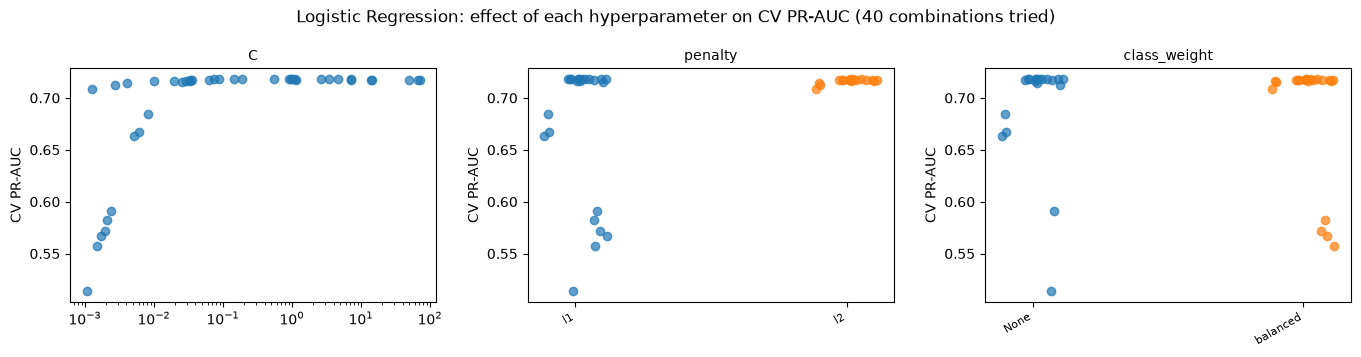

In [10]:
tc.plot_param_effects(MODEL_NAME, search)

## 5. Save results and the tuned model
Writes the CSV / JSON files read by `06e` and saves the tuned model (a plain scikit-learn model) to `models/tuned/`. **No test data is used.**

In [11]:
tc.save_search(MODEL_NAME, search)

{'cv_results': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_logistic_regression_cv_results.csv',
 'best_folds': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_logistic_regression_best_folds.csv',
 'summary': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_logistic_regression_summary.csv',
 'best_json': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_logistic_regression_best.json',
 'model': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\models\\tuned\\logistic_regression_tuned.pkl'}

## 6. Interpretation — coefficients of the tuned model

In [12]:
best = search.best_estimator_
clf = best.named_steps["clf"]
coefs = pd.Series(clf.coef_[0], index=X.columns)
print(f"penalty = {clf.penalty}, C = {clf.C:.4g}, class_weight = {clf.class_weight}")
print(f"Non-zero coefficients: {(coefs != 0).sum()} of {len(coefs)}")
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)
display(top.round(3).to_frame("coef"))
print("Ordinal features (impact / urgency / priority) coefficients:")
display(coefs[["impact_encoded", "urgency_encoded", "priority_encoded"]].round(3).to_frame("coef"))

penalty = l1, C = 0.1445, class_weight = None
Non-zero coefficients: 101 of 109


,coef
assignment_group_64,-0.705
assignment_group_20,0.587
u_symptom_534,-0.517
assignment_group_9,0.362
assignment_group_73,-0.247
u_symptom_532,0.229
opened_month,-0.225
category_61,0.204
category_57,0.196
subcategory_9,-0.191


Ordinal features (impact / urgency / priority) coefficients:


,coef
impact_encoded,0.005
urgency_encoded,0.000
priority_encoded,0.041


## 7. Observations
1. **Best configuration:** the search selected `C=0.1445`, `penalty="l1"` and `class_weight=None`. The lower `C` applies stronger regularisation than the baseline, while L1 regularisation can shrink weak one-hot feature coefficients toward zero.
2. **Little improvement over baseline:** tuned mean CV PR-AUC was **0.7183** (fold std **0.0735**), compared with **0.7178** for the best unweighted baseline, an improvement of only **0.0005**. ROC-AUC increased from **0.7501** to **0.7509**, while F1 changed from **0.6245** to **0.6226**, recall from **0.6252** to **0.6225**, precision from **0.6634** to **0.6632**, and accuracy from **0.6845** to **0.6837**.
3. **Stable, but variable across time:** fold PR-AUC ranged from **0.6656** to **0.8636**, with a spread of **0.1980**. Fold 1 was much stronger than the later folds, so the average score should be interpreted alongside the time-specific results.
4. **Limited overfitting:** training PR-AUC was **0.8289** versus validation PR-AUC **0.7183**, a gap of **0.1106**. Training accuracy was **0.7305** versus validation accuracy **0.6837**, a gap of **0.0468**. The smaller accuracy gap is consistent with logistic regression being less flexible than the tree-based models.
5. **Interpretability:** L1 regularisation left **101 of 109** coefficients non-zero, so it produced only modest sparsity. The strongest positive coefficients included `assignment_group_20`, `assignment_group_9` and `u_symptom_532`; the strongest negative coefficients included `assignment_group_64`, `u_symptom_534` and `assignment_group_73`. A positive coefficient increases the model's log-odds of reassignment, while a negative coefficient decreases them, holding other features constant.
6. **Conclusion:** tuning did not materially improve Logistic Regression, but it confirmed that the model is a stable and interpretable benchmark. Its limited flexibility and smaller train-validation gap are useful when comparing it with the higher-performing but more complex tree-based models. Final performance still requires confirmation on the sealed test set, and the tuned score is slightly optimistic because the best of 40 configurations was selected on the same cross-validation folds.